<a href="https://colab.research.google.com/github/rajanani6767/ML/blob/main/task7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Sample
   daily_time_spent  posts_per_week  likes_received  comments_received  \
0        131.125832       14.265073      225.876282         160.533718   
1        286.692863       11.185831      564.805900         148.962745   
2        227.638364        6.881025      879.298544          17.436199   
3        191.637791       16.462105      745.613642         108.961870   
4         72.125033       14.009892      816.233090         120.256729   

       shares    followers  
0   56.032608  8292.437329  
1   53.160866  7668.825167  
2  181.719643  5777.936619  
3   53.661509  9564.866722  
4   58.030197  2084.697704  

Dataset Shape: (500, 6)

Summary Statistics
       daily_time_spent  posts_per_week  likes_received  comments_received  \
count        500.000000      500.000000      500.000000         500.000000   
mean         164.611662       10.157076      541.680216         153.978182   
std           80.645870        5.424376      282.333286          83.232858   
min      

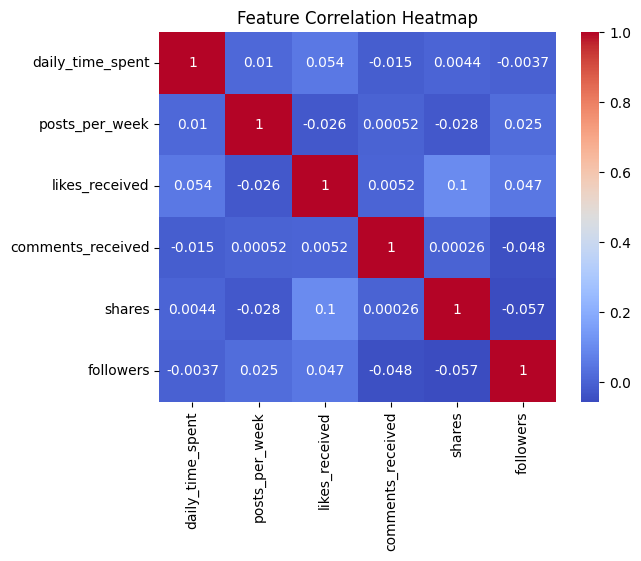


K-Means Cluster Counts
KMeans_cluster
2    175
0    163
1    162
Name: count, dtype: int64

Hierarchical Cluster Counts
Hierarchical_cluster
1    208
0    194
2     98
Name: count, dtype: int64


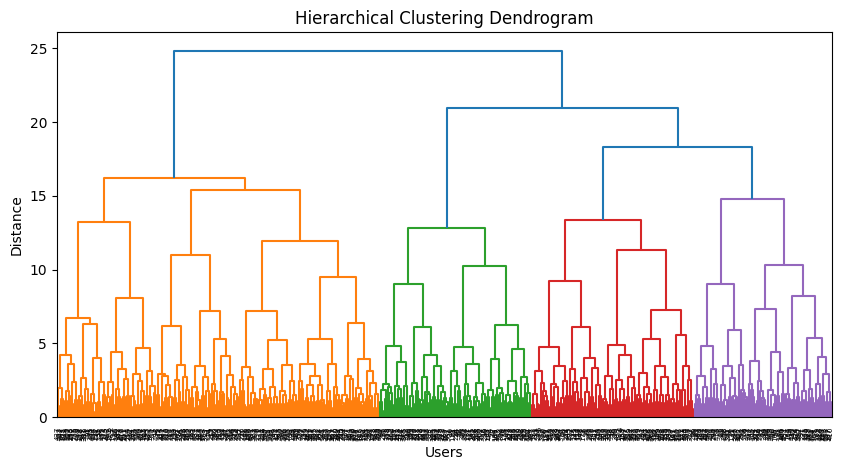


===== Clustering Evaluation =====

K-Means Results
Silhouette Score: 0.12716667937623535
Davies-Bouldin Index: 2.1370485531480137

Hierarchical Results
Silhouette Score: 0.08625507700806526
Davies-Bouldin Index: 2.5271940300040154


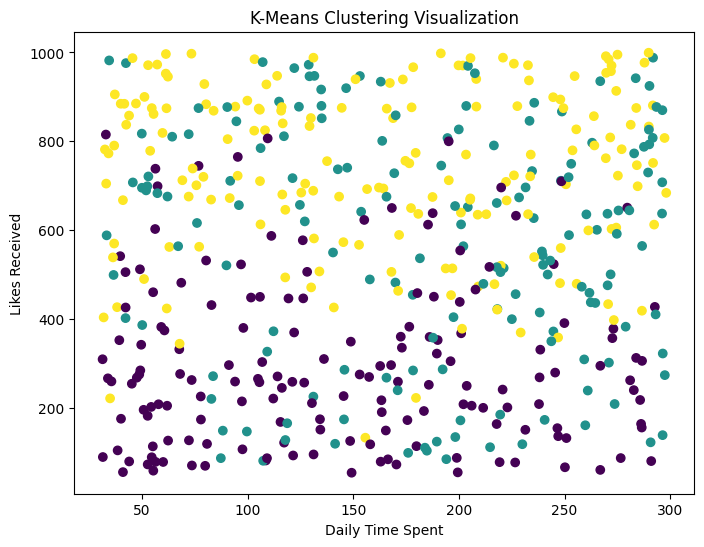

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

# ==========================================
# Create Large Social Media Dataset
# ==========================================

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "daily_time_spent": np.random.uniform(30,300,n),   # minutes per day
    "posts_per_week": np.random.uniform(1,20,n),
    "likes_received": np.random.uniform(50,1000,n),
    "comments_received": np.random.uniform(10,300,n),
    "shares": np.random.uniform(5,200,n),
    "followers": np.random.uniform(100,10000,n)
})

print("Dataset Sample")
print(data.head())

print("\nDataset Shape:",data.shape)

# ==========================================
# Exploratory Data Analysis
# ==========================================

print("\nSummary Statistics")
print(data.describe())

print("\nCorrelation Matrix")
print(data.corr())

sns.heatmap(data.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================================
# Data Scaling
# ==========================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

# ==========================================
# K-Means Clustering
# ==========================================

kmeans = KMeans(n_clusters=3,random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

data["KMeans_cluster"] = kmeans_labels

print("\nK-Means Cluster Counts")
print(data["KMeans_cluster"].value_counts())

# ==========================================
# Hierarchical Clustering
# ==========================================

hierarchical = AgglomerativeClustering(n_clusters=3)

hier_labels = hierarchical.fit_predict(scaled_data)

data["Hierarchical_cluster"] = hier_labels

print("\nHierarchical Cluster Counts")
print(data["Hierarchical_cluster"].value_counts())

# ==========================================
# Dendrogram
# ==========================================

plt.figure(figsize=(10,5))

linked = linkage(scaled_data,'ward')

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Users")
plt.ylabel("Distance")
plt.show()

# ==========================================
# Evaluation Metrics
# ==========================================

silhouette_kmeans = silhouette_score(scaled_data,kmeans_labels)
db_kmeans = davies_bouldin_score(scaled_data,kmeans_labels)

silhouette_hier = silhouette_score(scaled_data,hier_labels)
db_hier = davies_bouldin_score(scaled_data,hier_labels)

print("\n===== Clustering Evaluation =====")

print("\nK-Means Results")
print("Silhouette Score:",silhouette_kmeans)
print("Davies-Bouldin Index:",db_kmeans)

print("\nHierarchical Results")
print("Silhouette Score:",silhouette_hier)
print("Davies-Bouldin Index:",db_hier)

# ==========================================
# Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(data["daily_time_spent"],
            data["likes_received"],
            c=data["KMeans_cluster"],
            cmap="viridis")

plt.xlabel("Daily Time Spent")
plt.ylabel("Likes Received")

plt.title("K-Means Clustering Visualization")

plt.show()